<div style="background:linear-gradient(135deg,#1e1b4b 0%,#4338ca 55%,#6366f1 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#c7d2fe;font-weight:700;text-transform:uppercase">Chapter 78 · Hypothesis Testing &amp; Inference</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">ANOVA 📊</div>
  <div style="font-size:15px;color:#eef2ff;max-width:740px;line-height:1.6">When you have three or more groups, running every pairwise t-test inflates the error rate. ANOVA tests them all at once with the F statistic, and statsmodels' pairwise_tukeyhsd pinpoints which differ. We apply both to three shipping carriers.</div>
  <div style="margin-top:16px;font-size:13px;color:#c7d2fe">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

## ⚙️ Setup

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
# statsmodels = the R/SAS-style stats library (pre-installed on Colab): it computes the
# standard errors, test statistics, intervals, and post-hoc comparisons, so we write less by hand.
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.proportion import proportions_ztest, confint_proportions_2indep, proportion_confint
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.weightstats import DescrStatsW, CompareMeans
from scipy.stats.contingency import association   # Cramer's V in one call
IND="#4f46e5"; DEEP="#4338ca"; LIGHT="#818cf8"; INK="#1a2138"; GRID="#e6e9f2"; GREEN="#059669"; RED="#ef4444"; AMBER="#d97706"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
rng = np.random.default_rng(78)

<div style="background:#eef2ff;border-left:5px solid #4f46e5;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#4338ca;letter-spacing:1px">DEMO 1 · WHY NOT MANY t-TESTS?</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Comparing 3+ groups inflates the error rate</div>
<div style="color:#4a5578;margin-top:6px">With 3 groups there are 3 possible pairwise t-tests; with 5 groups, 10. Each carries a 5% false-alarm risk, so running them all balloons the chance of a spurious 'difference'. ANOVA tests 'are ALL the means equal?' in ONE test at one alpha.</div>
</div>

In [2]:
from itertools import combinations
# simulate: 5 groups, all identical (H0 true). How often does ANY pairwise t-test fire?
def any_pairwise_hit(k=5,n=30):
    gs=[rng.normal(0,1,n) for _ in range(k)]
    return any(stats.ttest_ind(a,b).pvalue<0.05 for a,b in combinations(gs,2))
rate=np.mean([any_pairwise_hit() for _ in range(3000)])
print(f"5 identical groups: P(at least one pairwise t-test significant) = {rate:.2f}")
print("Far above 0.05 -> multiple comparisons inflate the family-wise error. ANOVA fixes this.")

5 identical groups: P(at least one pairwise t-test significant) = 0.27
Far above 0.05 -> multiple comparisons inflate the family-wise error. ANOVA fixes this.


Ten independent 5% tests give roughly a 1&#8722;0.95&#185;&#8304; &#8776; 40% chance of at least one false alarm. ANOVA restores a single, honest 5% by asking one global question first: <em>is there any difference at all?</em>

<div style="background:#eef2ff;border-left:5px solid #4f46e5;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#4338ca;letter-spacing:1px">DEMO 2 · THE F STATISTIC</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Between-group spread vs within-group spread</div>
<div style="color:#4a5578;margin-top:6px">ANOVA compares two kinds of variation. If the group means are far apart RELATIVE to the noise within groups, their ratio, the F statistic, is large. F = (variance between group means) / (variance within groups). Under H0 (all equal), F is near 1.</div>
</div>

In [3]:
# three groups with genuinely different means
g1=rng.normal(50,8,40); g2=rng.normal(55,8,40); g3=rng.normal(62,8,40)
F,p=stats.f_oneway(g1,g2,g3)
print(f"means: {g1.mean():.1f}, {g2.mean():.1f}, {g3.mean():.1f}")
print(f"F={F:.2f}, p={p:.2e}  -> reject H0: not all means are equal")
# contrast: three IDENTICAL groups -> F near 1, p large
h=[rng.normal(50,8,40) for _ in range(3)]; F0,p0=stats.f_oneway(*h)
print(f"identical groups: F={F0:.2f}, p={p0:.2f}  -> fail to reject (as expected)")

means: 49.1, 56.2, 61.7
F=24.88, p=9.95e-10  -> reject H0: not all means are equal
identical groups: F=1.09, p=0.34  -> fail to reject (as expected)


A large F means the gaps between group means dwarf the within-group noise, evidence the groups really differ. Under the null, between and within variation are the same kind of thing, so F hovers around 1. The p-value comes from the F distribution with (k&#8722;1, N&#8722;k) degrees of freedom.

<div style="background:#eef2ff;border-left:5px solid #4f46e5;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#4338ca;letter-spacing:1px">DEMO 3 · POST-HOC: TUKEY HSD</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">A significant F says 'someone differs', but who?</div>
<div style="color:#4a5578;margin-top:6px">ANOVA's F is an omnibus test: it flags that SOME pair differs, not which. Tukey's Honest Significant Difference compares every pair while controlling the family-wise error rate. We do NOT code it by hand, statsmodels' pairwise_tukeyhsd does it in one call and prints a tidy table.</div>
</div>

In [4]:
# pairwise_tukeyhsd was imported in the setup cell; one call replaces a whole loop
g1=rng.normal(50,8,50); g2=rng.normal(52,8,50); g3=rng.normal(60,8,50)
vals=np.concatenate([g1,g2,g3]); labels=["A"]*50+["B"]*50+["C"]*50
F,p=stats.f_oneway(g1,g2,g3); print(f"ANOVA F={F:.2f}, p={p:.2e}\n")
print(pairwise_tukeyhsd(vals, labels).summary())

ANOVA F=18.24, p=8.37e-08

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     A      B  -0.7997 0.8681 -4.5351  2.9357  False
     A      C   7.8242    0.0  4.0888 11.5595   True
     B      C   8.6238    0.0  4.8885 12.3592   True
----------------------------------------------------


One function call, no hand-coded loops. Each row compares a pair: <code>reject=True</code> means that pair differs (its confidence interval excludes 0). Tukey widens each comparison just enough to keep the <em>overall</em> error at 5%, the disciplined way to follow up a significant ANOVA.

<div style="background:#ecfdf5;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#047857;letter-spacing:1px">REAL-WORLD EXAMPLE · DELIVERY BY CARRIER</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Do three carriers really differ on delivery time?</div>
<div style="color:#4a5578;margin-top:6px"></div>
</div>

A shipper compares <strong>three carriers</strong> on door-to-door delivery time (`ch78_carrier_delivery.xlsx`), 80 shipments each. Are the average times genuinely different, or is it noise? We explore first, then run ANOVA and Tukey, both from statsmodels.

In [5]:
try:    d = pd.read_excel("../../data/ch78_carrier_delivery.xlsx", sheet_name="Shipments")
except FileNotFoundError: d = pd.read_excel(BASE+"ch78_carrier_delivery.xlsx", sheet_name="Shipments")
# EXPLORE FIRST: size, missing values, and a per-carrier summary
print("shape:", d.shape, "| missing:", d.isna().sum().sum())
print(d.groupby("carrier").delivery_hours.agg(["size","mean","std","median"]).round(2))

shape: (240, 4) | missing: 0
             size   mean   std  median
carrier                               
FastFreight    80  30.39  7.05   31.30
GroundLink     80  35.87  5.92   35.94
RegionalCo     80  37.40  7.59   36.31


Levene equal-variance   p = 0.095  -> variances similar; classic ANOVA is valid
Shapiro residual-normal p = 0.276  -> residuals look normal
Kruskal-Wallis cross-check p = 3.1e-09  (distribution-free, should agree with ANOVA)


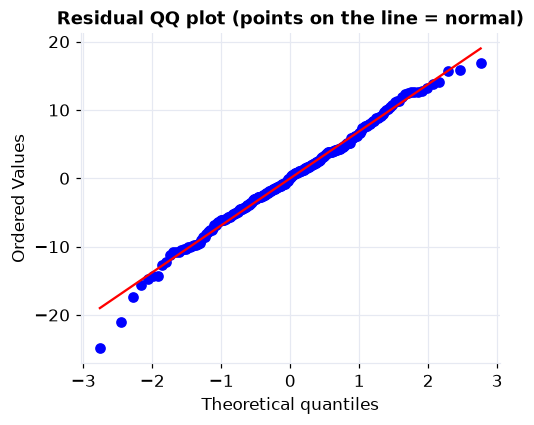

In [6]:
# CHECK ASSUMPTIONS before trusting the F-test (independence holds by the study design).
from scipy.stats import levene, shapiro, kruskal
groups = [g.delivery_hours.values for _, g in d.groupby("carrier")]
resid  = np.concatenate([g - g.mean() for g in groups])   # pooled within-group residuals
lev = levene(*groups)   # equal variance across carriers (robust to non-normality)
sh  = shapiro(resid)    # normality of the residuals
print(f"Levene equal-variance   p = {lev.pvalue:.3f}  -> "
      + ("variances similar; classic ANOVA is valid" if lev.pvalue>0.05 else "variances differ; use Welch ANOVA"))
print(f"Shapiro residual-normal p = {sh.pvalue:.3f}  -> "
      + ("residuals look normal" if sh.pvalue>0.05 else "non-normal; lean on the large n or use Kruskal-Wallis"))
print(f"Kruskal-Wallis cross-check p = {kruskal(*groups).pvalue:.1e}  (distribution-free, should agree with ANOVA)")
# a residual QQ plot makes the normality check visual
fig, ax = plt.subplots(figsize=(4.8,4)); stats.probplot(resid, dist="norm", plot=ax)
ax.set_title("Residual QQ plot (points on the line = normal)"); plt.tight_layout(); plt.show()

Before reading the F-test we **check its assumptions**, because a significant p-value is only trustworthy if the test's conditions hold. **Independence** is guaranteed by design (each row is one separate shipment). **Levene's test** (p = 0.10) says the three carriers' variances are close enough, and the **residual QQ plot** plus **Shapiro** (p = 0.28) show the residuals are roughly normal, so the classic ANOVA is valid here. When those checks FAIL you do not drop the question, you switch tools: unequal variances call for **Welch's ANOVA** (`pingouin.welch_anova(dv='delivery_hours', between='carrier', data=d)`), and heavy non-normality calls for the rank-based **Kruskal-Wallis** test (`scipy.stats.kruskal`). As a safety net we ran Kruskal-Wallis anyway and it agrees with ANOVA (p about 3e-9): the carriers really do differ.

               sum_sq     df   mean_sq       F  PR(>F)
C(carrier)   2173.764    2.0  1086.882  22.914     0.0
Residual    11241.803  237.0    47.434     NaN     NaN

eta^2 = 0.162  |  omega^2 = 0.154  (carrier explains about 15% of delivery-time variance, bias-corrected)

Tukey HSD (which carriers differ?):
    Multiple Comparison of Means - Tukey HSD, FWER=0.05    
   group1     group2   meandiff p-adj  lower  upper  reject
-----------------------------------------------------------
FastFreight GroundLink   5.4793    0.0 2.9109 8.0476   True
FastFreight RegionalCo   7.0106    0.0 4.4423  9.579   True
 GroundLink RegionalCo   1.5314 0.3393 -1.037 4.0997  False
-----------------------------------------------------------


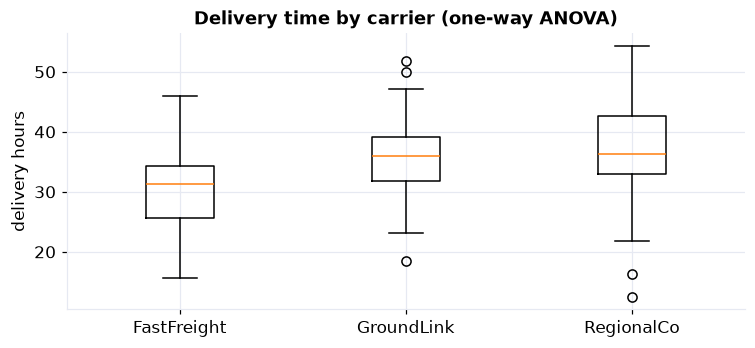

In [7]:
# ANOVA via a formula (like R: hours ~ carrier), then read the table from statsmodels
model = ols("delivery_hours ~ C(carrier)", data=d).fit()
aov = sm.stats.anova_lm(model, typ=2)
aov["mean_sq"] = aov["sum_sq"] / aov["df"]          # MS = SS / df: the variance each row represents
aov = aov[["sum_sq", "df", "mean_sq", "F", "PR(>F)"]]
ss_b = aov.loc["C(carrier)", "sum_sq"]; ms_w = aov.loc["Residual", "mean_sq"]; ss_t = aov["sum_sq"].sum()
eta2   = ss_b / ss_t
omega2 = (ss_b - aov.loc["C(carrier)", "df"] * ms_w) / (ss_t + ms_w)   # bias-corrected effect size
print(aov.round(3))
print(f"\neta^2 = {eta2:.3f}  |  omega^2 = {omega2:.3f}  (carrier explains about {omega2*100:.0f}% of delivery-time variance, bias-corrected)")
print("\nTukey HSD (which carriers differ?):")
print(pairwise_tukeyhsd(d.delivery_hours, d.carrier).summary())
fig,ax=plt.subplots(figsize=(7,3.3))
ax.boxplot([g.delivery_hours.values for _,g in d.groupby("carrier")], tick_labels=list(d.groupby("carrier").groups))
ax.set_ylabel("delivery hours"); ax.set_title("Delivery time by carrier (one-way ANOVA)")
plt.tight_layout(); plt.show()

The F statistic is about <strong>22.9</strong> with a p-value near 10&#8315;&#8313;, so we reject the hypothesis that all three carriers deliver equally fast; carrier explains about <strong>16%</strong> of the variation (&#951;&#178; &#8776; 0.16). The Tukey table shows FastFreight (&#8776; 30.4 h) is significantly faster than both GroundLink (&#8776; 35.9 h) and RegionalCo (&#8776; 37.4 h), while GroundLink and RegionalCo are not clearly distinguishable. The omnibus test plus the post-hoc gives the full picture: there is a difference, and it is FastFreight pulling ahead. Read the table left to right: each **sum of squares** (SS) is a pile of variation, **df** its degrees of freedom, and **MS = SS/df** the variance it stands for; the **F** ratio is the between-carrier MS (about 1087) over the within-carrier MS (about 47), so carriers vary roughly 23 times more than shipments within a carrier. The bias-corrected **omega-squared (0.15)** sits just below eta-squared and is the number to report. In publication form: *a one-way ANOVA showed delivery time differed by carrier, F(2, 237) = 22.91, p < .001, omega-squared = 0.15; Tukey HSD placed FastFreight (30.4 h) below both GroundLink (35.9 h) and RegionalCo (37.4 h), which did not differ.*

<div style="background:#ffffff;border:1px solid #e6e9f2;border-radius:16px;padding:22px 26px;font-family:Inter,sans-serif">
<div style="font-size:19px;font-weight:800;color:#1a2138">✅ ANOVA</div>
<div style="color:#4a5578;line-height:1.8;margin-top:8px">ANOVA compares 3+ group means in one test, avoiding the error inflation of many t-tests. The F statistic is between-group variance over within-group variance; large F (small p) rejects "all means equal". A significant F is an omnibus result, so follow it with Tukey HSD (statsmodels&#39; pairwise_tukeyhsd) to see WHICH pairs differ. On real data, carriers differ (F=22.9, p&#8776;10&#8315;&#8313;, &#951;&#178;&#8776;0.16) with FastFreight the standout. Next: chi-square tests for categorical data.</div></div>

---
<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:10px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>